Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython
cl = ['r', 'g', 'b', 'c', 'm', 'y', '#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf']
t[[360.           1.05086957   1.74480626   4.        ]]
t[[400.           1.08412729   1.80857956   6.        ]]
t[[450.     1.24   1.57   8.  ]]
t[[490.           1.1282571    1.74498554  10.        ]]
t[[530.           1.17723814   1.68443586  12.        ]]
t[[570.           1.18964452   1.66433168  14.        ]]
t[[645.     0.84   2.27  16.  ]]
t[[650.           1.18526197   1.69636306  18.        ]]


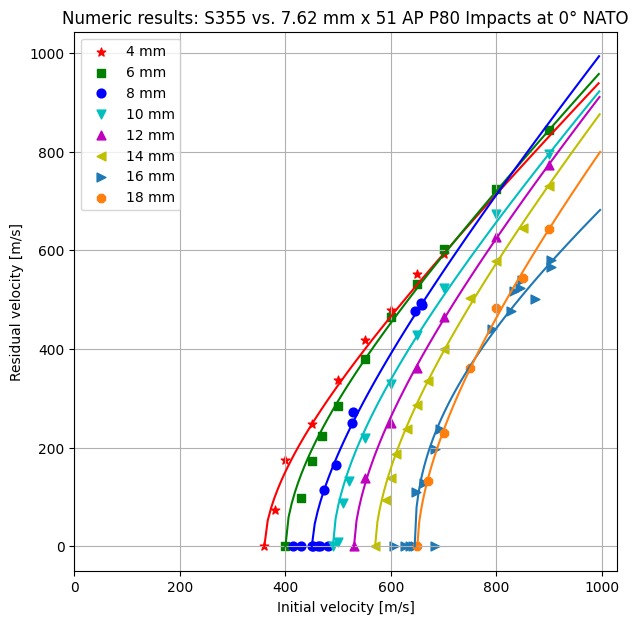

In [1]:
##############################
# Load and plot original data
# 2026-03-18_11-30-02 - tu są wyniki!!!
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
import math
import pickle
import os
from datetime import datetime

from jupyter_server.utils import path2url
from pysr import PySRRegressor, TemplateExpressionSpec

#dane = np.genfromtxt('data/dane_2026-03-16.txt', delimiter=';', skip_header=1)
#wspolczynniki = np.genfromtxt('data/wspolczynniki_2026-03-16.txt', delimiter=';', skip_header=1)

#dane = np.genfromtxt('data/dane_2026-03-16.txt', delimiter=';', skip_header=1)
#wspolczynniki = np.genfromtxt('data/wspolczynniki_2026-03-16.txt', delimiter=';', skip_header=1)

dane = np.genfromtxt('data/dane_2026-03-17_exp_num.txt', delimiter=';', skip_header=1)
wspolczynniki = np.genfromtxt('data/wspolczynniki_2026-03-17_exp_num.txt', delimiter=';', skip_header=1)

def make_sequence(start_seq, end_seq, number_points):
    step = (end_seq - start_seq) / number_points
    vi_list = []
    a = 0
    actual_value = start_seq
    while a < number_points:
        actual_value = start_seq + a * step
        vi_list.append(actual_value)
        a = a + 1
    vi = np.array(vi_list)
    vi = np.sort(vi)
    return vi

def Vr(Vi, a, P, V_bl):
    res = np.zeros(Vi.shape[0])
    for id in range(Vi.shape[0]):
        p1 = math.pow(Vi[id], P) - math.pow(V_bl, P)
        if p1 > 0:
            p2 = a * math.pow(p1,1./P)
        else:
            p2 = 0
        res[id] = p2
    return res


plt.subplots(figsize=(7, 7))
#t = 18
color_list = ['r', 'g', 'b', 'c', 'm', 'y'] + list(mcolors.TABLEAU_COLORS.values())
markers = ["*", ",", "o", "v", "^", "<", ">", "8", "s", "p", "P", "h", "X", "D", "d"]
print('cl = ' + str(color_list))
id_color = 0
for t in range(4, 19, 2):
    wsp = wspolczynniki[wspolczynniki[:,3] == t]
    dd = dane[dane[:,2] == t]
    print('t' + str(wsp))
    #print(dd)
    vbl = wsp[0, 0]
    aa = wsp[0, 1]
    pp = wsp[0, 2]
    vi = make_sequence(vbl, 1000, 100)
    vir = Vr(vi, aa, pp, vbl)


    plt.scatter(dd[:,0], dd[:,1], c=color_list[id_color], label=str(t) + ' mm', marker=markers[id_color], s=40)
    #plt.plot(vi, vir, c=color_list[id_color], ls='-', label='RL,Vbl=%5.0f m/s, a=%5.2f, p=%5.1f' % tuple([vbl, aa,pp]))
    plt.plot(vi, vir, c=color_list[id_color], ls='-')
    id_color += 1
plt.xlabel('Initial velocity [m/s]')
plt.ylabel('Residual velocity [m/s]')
plt.title('Numeric results: S355 vs. 7.62 mm x 51 AP P80 Impacts at 0° NATO')
plt.xlim(xmin=0)
plt.legend()
plt.grid()

In [104]:
"""
###########################################3
# Symbolic regression for all thicknesses
data_l_X = []
data_l_y = []
for t in wspolczynniki[:,3].tolist():
    #dd = dane[dane[:,2] == t]
    wsp = wspolczynniki[wspolczynniki[:,3] == t]
    #print('t' + str(wsp))
    #print(dd)
    vbl = wsp[0, 0]
    aa = wsp[0, 1]
    pp = wsp[0, 2]
    vi = make_sequence(vbl, 1000, 100)
    vir = Vr(vi, aa, pp, vbl)
    XX_ = np.column_stack((vi, np.repeat(t,vi.shape[0])))
    data_l_X.append(XX_)
    data_l_y.append(vir)

XX_full = np.concatenate(data_l_X, axis=0)
y_full = np.concatenate(data_l_y, axis=0)
wspolczynniki_list = wspolczynniki[:,3].tolist()
"""

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import math
import matplotlib.colors as mcolors
from prompt_toolkit.shortcuts import confirm
from tqdm import tqdm

def calculate_pdf(min_val, max_val, step, my_function, frac = [1,1,1]):
    frac = np.asarray(frac)
    if np.sum(frac) < 0.0001:
        frac = np.asarray([1,1,1])
    frac = frac / np.sum(frac)

    border_left = 10 * step
    border_right = 10 * step
    grid_help = np.mgrid[min_val-border_left:max_val+border_right:step]
    x = grid_help
    y = my_function(grid_help)
    y_grad = np.abs(np.gradient(y))
    y_grad2 = np.abs(np.gradient(y_grad))

    x_ = x[10:-10]
    y_ = y[10:-10]
    y_grad_ = y_grad[10:-10]
    y_grad2_ = y_grad2[10:-10]

    y_pdf = np.zeros(y_grad2_.shape)
    y_pdf[0] = frac[0] * step + frac[1] * y_grad_[0] + frac[2] * y_grad2_[0]

    for i in range(1, y_pdf.shape[0]):
        val = frac[0] * step + frac[1] * y_grad_[i] + frac[2] * y_grad2_[i]
        y_pdf[i] = y_pdf[i-1] + val

    y_pdf_max = np.max(y_pdf)
    y_pdf /= y_pdf_max
    return (y_pdf, x_, y_, y_grad_, y_grad2_)

def plot_pdf(y_pdf, x_, y_, y_grad_, y_grad2_):
    plt.plot(x_, y_, color='r')
    plt.show()
    plt.plot(x_, y_grad_, color='b')
    plt.show()
    plt.plot(x_, y_grad2_, color='g')
    plt.show()
    plt.plot(x_, y_pdf, color='y')
    plt.show()

def sample_from_pdf(y_pdf, x_, y_, sample_size):
    r_n = np.random.rand(sample_size)
    rx = np.zeros(sample_size)
    ry = np.zeros(sample_size)
    for i in range(len(r_n)):
        a = 0
        while r_n[i] > y_pdf[a]:
            a += 1
        rx[i] = x_[a]
        ry[i] = y_[a]
    return rx, ry

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


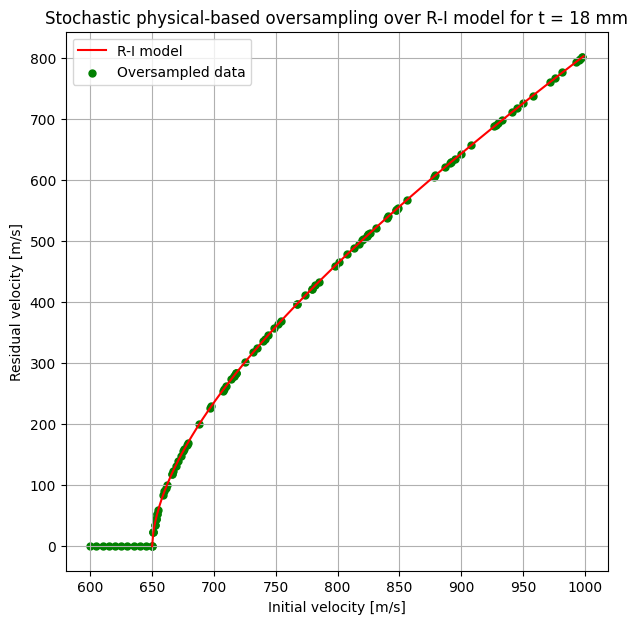

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


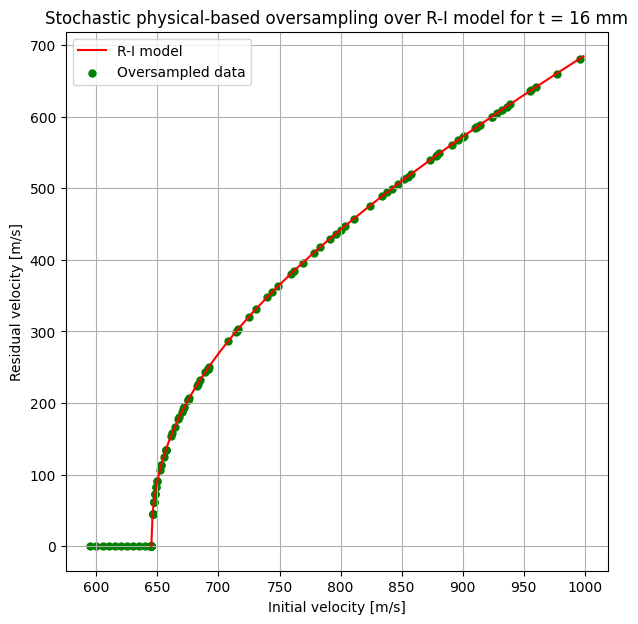

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


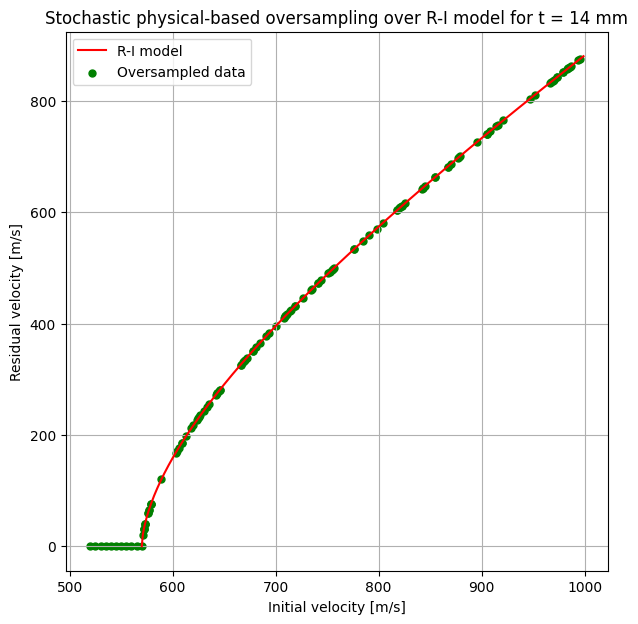

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


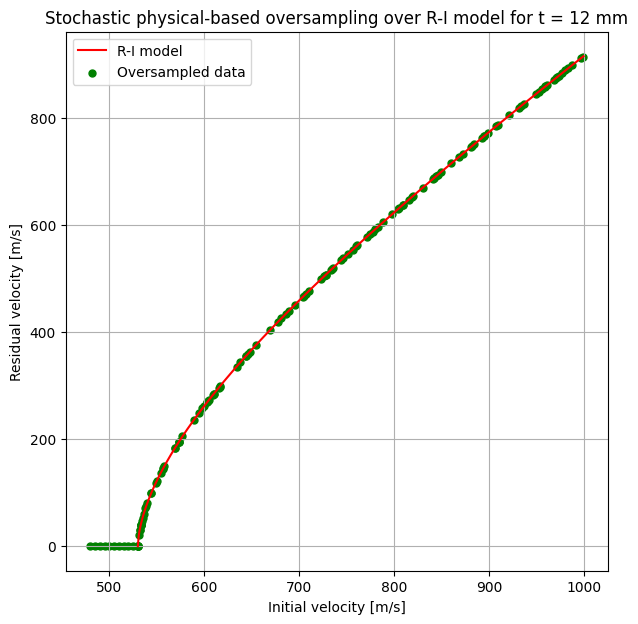

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


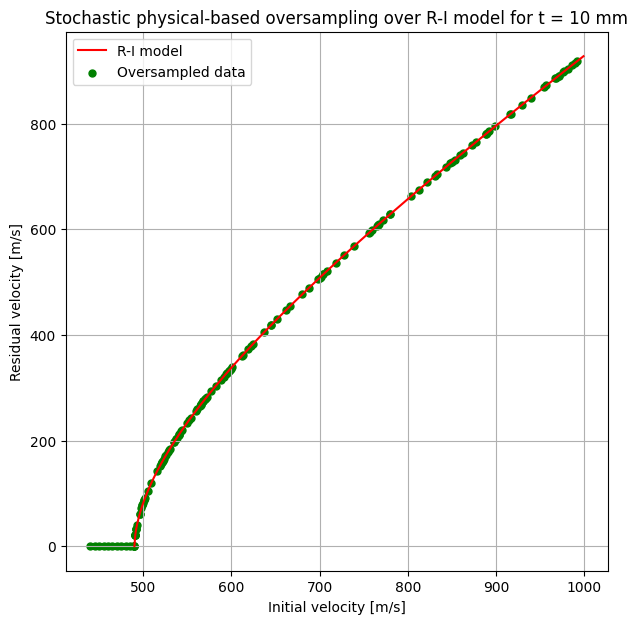

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


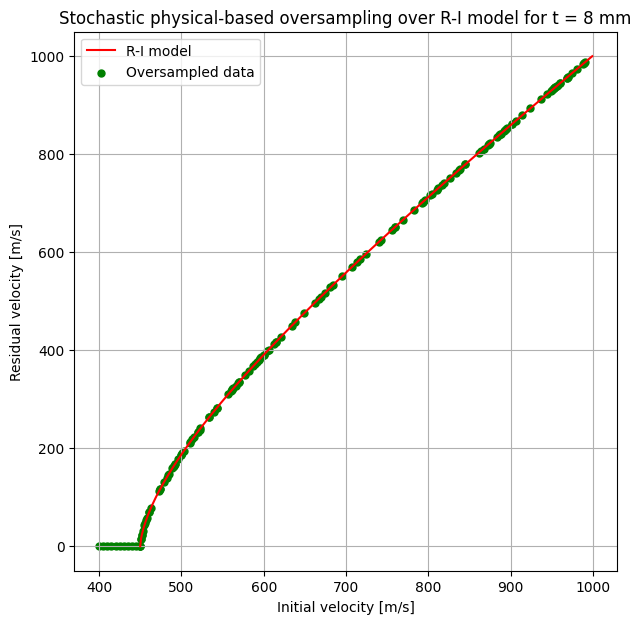

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


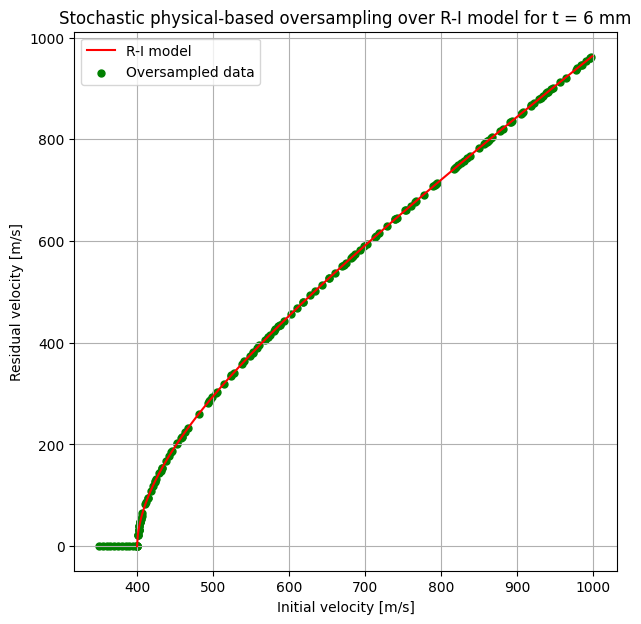

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


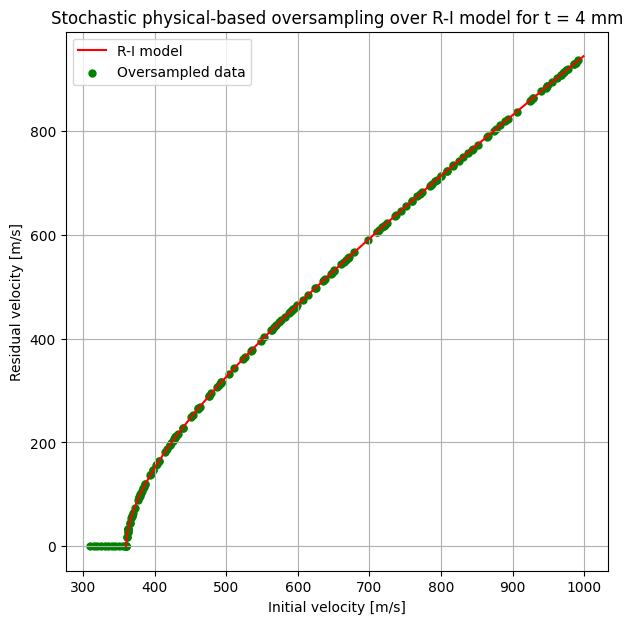

In [3]:
dane_extended = []
sample_size = 100
max_val = 1000
step = 1
frac = 0.99
frac = 0.5
#frac = [1, 0, 0]
#frac = [1, 1, 1]
#frac = [0, 0.01, 0.99]
#NOWE
#frac = [0, 0.5, 0.5]
#NOWE
frac = [0, 0.25, 0.75]
#frac = [0, 0, 1]

wspolczynniki_list = wspolczynniki[:,3].tolist()

full_data = []

for thickness in wspolczynniki_list:
    wsp = wspolczynniki[wspolczynniki[:,3] == thickness]
    vbl = wsp[0, 0]
    aa = wsp[0, 1]
    pp = wsp[0, 2]
    grid_help = np.mgrid[vbl-10:max_val:step]

    def function_helper(grid):
        y = Vr(grid, aa, pp, vbl)
        return y


    (y_pdf, x_, y_, y_grad_, y_grad2_) = calculate_pdf(vbl, 1000, 1, function_helper, frac)
    #plot_pdf(y_pdf, x_, y_, y_grad_, y_grad2_)
    rx, ry = sample_from_pdf(y_pdf, x_, y_, sample_size)

    rx_add = np.arange(vbl - 50, vbl, 5).tolist()
    ry_add = np.zeros(len(rx_add)).tolist()
    rx_add.extend(rx)
    ry_add.extend(ry)
    rx = rx_add
    ry = ry_add


    sample_size = len(rx)
    #which_to_find_bool = np.abs(data_full[:,1] - thickness) < 0.0001
    #data_help = data_full[which_to_find_bool]

    fig, ax = plt.subplots(figsize=(7, 7))
    plt.plot(x_, y_, color='r', label='R-I model')
    plt.scatter(rx, ry, marker='.', color='g', label='Oversampled data', s=100)
    #plt.scatter(data_help[:,0], data_help[:,2], marker='.', color='b')
    plt.title('Stochastic physical-based oversampling over R-I model for t = ' + str(int(thickness)) + " mm")


    #plt.title("SR on test data t = " + str(int(t)) + " mm" + ", Vbl = " + str(int(vbl_)) + " m/s, est. Vbl = " + str(int(vbl(t))) + " m/s")

    #plt.title("Prediction on test dataset t = " + str(int(t)) + " mm" + ", Vbl = " + str(int(vbl_)) + ", estimated Vbl = XXX")
    #ax.plot(vi_, vr_list, c=color_list[id_color + 1], ls='-', label='SR approximation')

    plt.xlabel('Initial velocity [m/s]')
    plt.ylabel('Residual velocity [m/s]')

    ax.legend()
    plt.grid()

    plt.savefig("./figures/oversampling_" + str(int(thickness)) + ".eps", dpi=300, format='eps', bbox_inches="tight")
    plt.show()



    numeric_series = np.array([rx, np.repeat(thickness, sample_size), ry]).transpose()
    full_data.extend(numeric_series)
    #dane_extended = np.concatenate((dane_extended, numeric_series))



full_data_numpy = np.array(full_data)

#np.savetxt('full_data_numpy_025_075.csv', full_data_numpy)
#full_data_numpy = np.loadtxt('full_data_numpy_025_075.csv')

XX_full = full_data_numpy[:,0:2]
y_full = full_data_numpy[:,2]


In [35]:
rx

[310.0,
 312.0,
 314.0,
 316.0,
 318.0,
 320.0,
 322.0,
 324.0,
 326.0,
 328.0,
 330.0,
 332.0,
 334.0,
 336.0,
 338.0,
 340.0,
 342.0,
 344.0,
 346.0,
 348.0,
 350.0,
 352.0,
 354.0,
 356.0,
 358.0,
 np.float64(403.0),
 np.float64(386.0),
 np.float64(581.0),
 np.float64(932.0),
 np.float64(969.0),
 np.float64(368.0),
 np.float64(568.0),
 np.float64(568.0),
 np.float64(362.0),
 np.float64(931.0),
 np.float64(360.0),
 np.float64(727.0),
 np.float64(484.0),
 np.float64(546.0),
 np.float64(539.0),
 np.float64(633.0),
 np.float64(934.0),
 np.float64(672.0),
 np.float64(873.0),
 np.float64(380.0),
 np.float64(629.0),
 np.float64(973.0),
 np.float64(544.0),
 np.float64(462.0),
 np.float64(791.0),
 np.float64(472.0),
 np.float64(555.0),
 np.float64(427.0),
 np.float64(595.0),
 np.float64(697.0),
 np.float64(998.0),
 np.float64(696.0),
 np.float64(842.0),
 np.float64(751.0),
 np.float64(920.0),
 np.float64(395.0),
 np.float64(364.0),
 np.float64(820.0),
 np.float64(722.0),
 np.float64(614.0),


In [38]:
XX_full

array([[600.,  18.],
       [605.,  18.],
       [610.,  18.],
       ...,
       [911.,   4.],
       [948.,   4.],
       [404.,   4.]], shape=(1160, 2))

In [4]:
folder_name = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")

# Utwórz katalog
os.makedirs("./results/" + folder_name, exist_ok=True)

print(f"Output directory: {folder_name}")


Output directory: 2026-03-20_22-44-51


In [5]:
def train_random_forest_regressor(XX_full_train, y_full_train):

    import xgboost as xgb
    reg = xgb.XGBRegressor(tree_method="hist", device="cuda")
    # Fit the model using predictor X and response y.
    reg.fit(XX_full_train, y_full_train)
    return reg


In [6]:
for t in wspolczynniki_list:
    print("Thickness: " + str(t) + " mm")
    XX_full_train_ids = XX_full[:, 1] != t
    XX_full_test_ids = XX_full[:, 1] == t

    XX_full_train = XX_full[XX_full_train_ids]
    XX_full_test = XX_full[XX_full_test_ids]
    y_full_train = y_full[XX_full_train_ids]
    y_full_test = y_full[XX_full_test_ids]

    np.savetxt('./results/test_folder/XX_full_train_' + str(t) + '.csv', XX_full_train)
    np.savetxt('./results/test_folder/XX_full_test_' + str(t) + '.csv', XX_full_test)
    np.savetxt('./results/test_folder/y_full_train_' + str(t) + '.csv', y_full_train)
    np.savetxt('./results/test_folder/y_full_test_' + str(t) + '.csv', y_full_test)

    out_model = train_random_forest_regressor(XX_full_train, y_full_train)
    path_help = './results/' + folder_name + '/xgb_model_t=' + str(t) + '.pkl'

    with open(path_help, 'wb') as file:
        pickle.dump(out_model, file)


Thickness: 18.0 mm


D:\Projects\Python\PycharmProjects\WebScrapper\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [22:44:57] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\context.cc:53: No visible GPU is found, setting device to CPU.
  bst.update(dtrain, iteration=i, fobj=obj)
D:\Projects\Python\PycharmProjects\WebScrapper\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [22:44:57] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\context.cc:207: Device is changed from GPU to CPU as we couldn't find any available GPU on the system.
  bst.update(dtrain, iteration=i, fobj=obj)


Thickness: 16.0 mm
Thickness: 14.0 mm
Thickness: 12.0 mm
Thickness: 10.0 mm
Thickness: 8.0 mm
Thickness: 6.0 mm
Thickness: 4.0 mm


In [7]:
from scipy.ndimage import gaussian_filter

def central_difference(val_array, my_id):
    my_id = int(my_id)
    if my_id <= 0:
        my_id = 0
        return val_array[my_id + 1] - val_array[my_id]
    elif my_id >= val_array.shape[0] - 1:
        my_id = val_array.shape[0] - 1
        return val_array[my_id] - val_array[my_id - 1]
    else:
        return (val_array[my_id + 1] - val_array[my_id - 1]) / 2

def find_B_bl(my_pred, my_numeric_series):
    my_pred = np.copy(my_pred)
    my_pred = gaussian_filter(my_pred, sigma=2)

    V_bl_id_pred = 0
    while V_bl_id_pred < my_pred.shape[0] and (my_pred[V_bl_id_pred] <= 30 or (central_difference(my_pred, V_bl_id_pred-1) <= 0 or central_difference(my_pred, V_bl_id_pred) <= 0 or central_difference(my_pred, V_bl_id_pred + 1) <= 0)):
        V_bl_id_pred += 1
    if V_bl_id_pred >= my_pred.shape[0]:
        V_bl_id_pred = my_pred.shape[0] - 1
    print(my_numeric_series.shape)
    return my_numeric_series[V_bl_id_pred]

t[[650.           1.18526197   1.69636306  18.        ]]


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


(1000,)
t[[645.     0.84   2.27  16.  ]]


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


(1000,)
t[[570.           1.18964452   1.66433168  14.        ]]


...

(1000,)
t[[400.           1.08412729   1.80857956   6.        ]]


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


(1000,)
t[[360.           1.05086957   1.74480626   4.        ]]


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


(1000,)


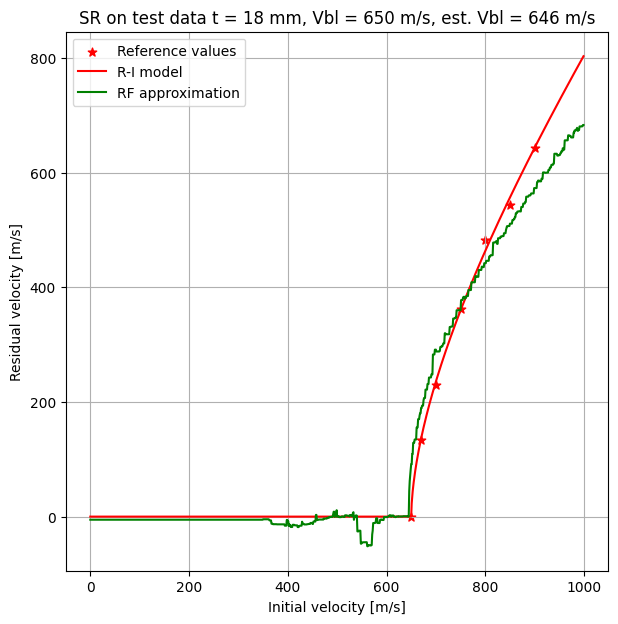

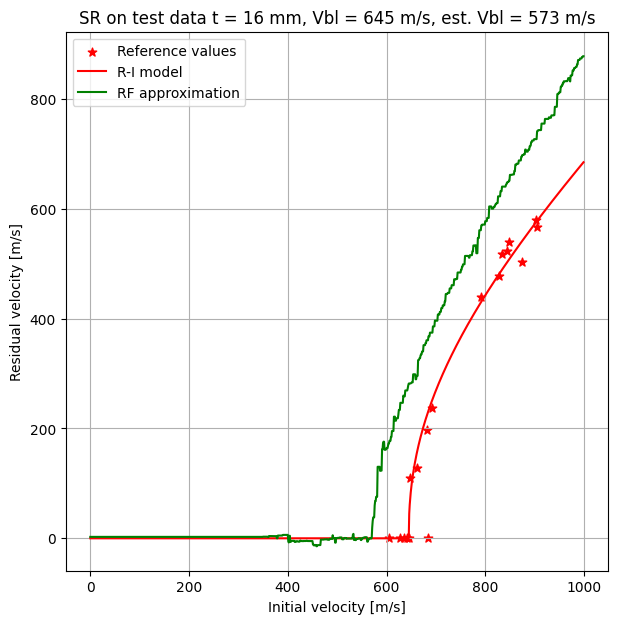

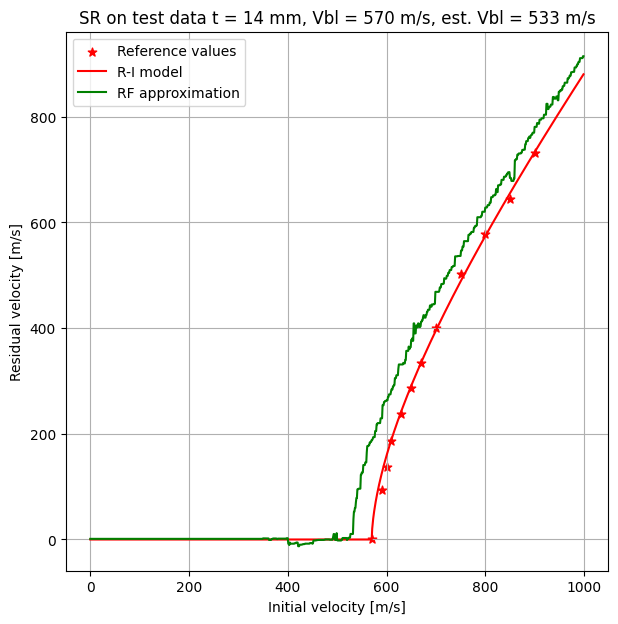

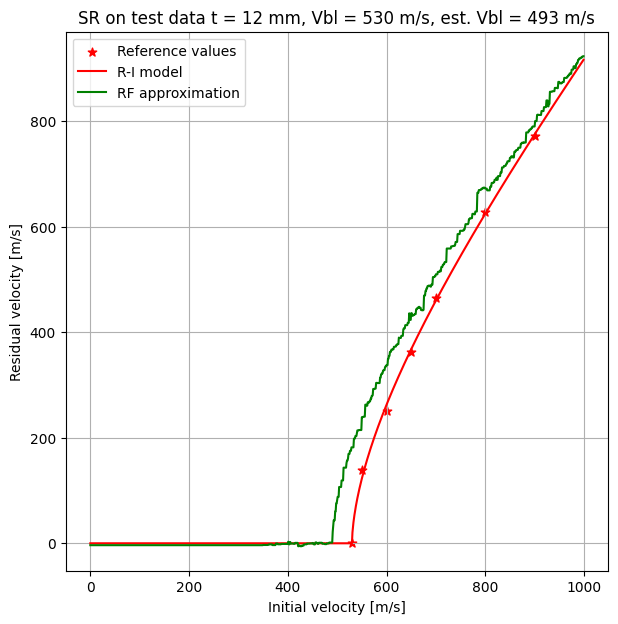

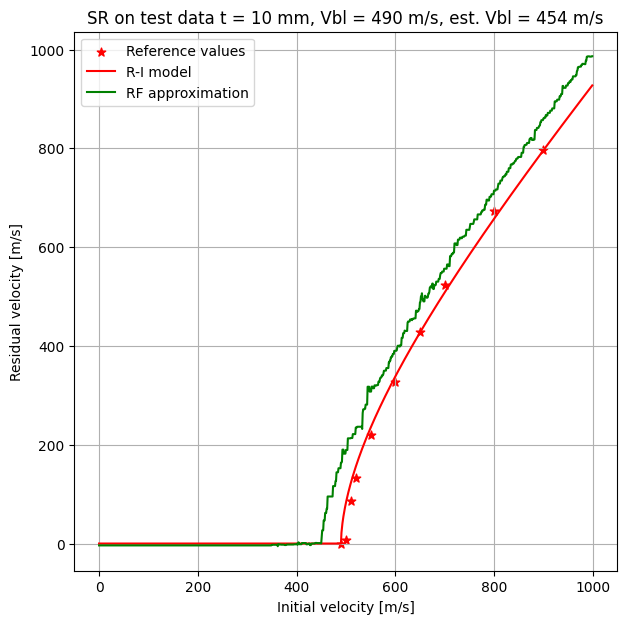

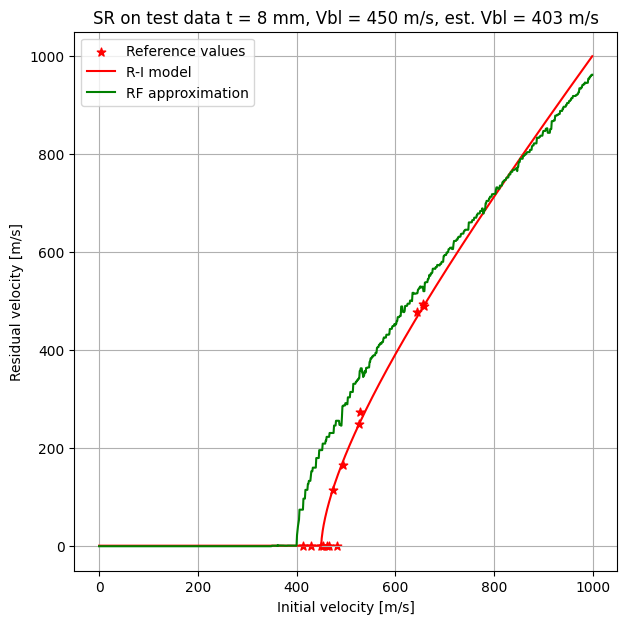

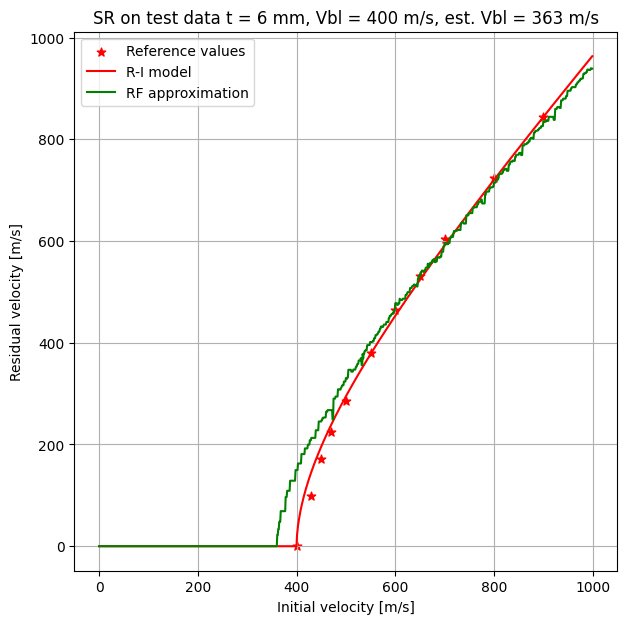

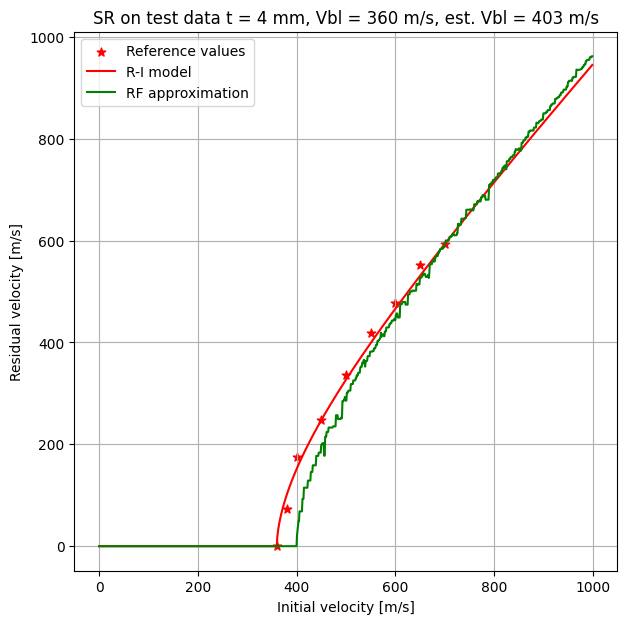

In [14]:
list_vr = []
list_vr_est = []
list_vbl = []
list_vbl_est = []

for t in wspolczynniki_list:
    path_help = './results/' + folder_name + '/xgb_model_t=' + str(t) + '.pkl'
    with open(path_help, 'rb') as file:
        regr = pickle.load(file)

    fig, ax = plt.subplots(figsize=(7, 7))


    id_color = 0
    wsp = wspolczynniki[wspolczynniki[:,3] == t]
    dd = dane[dane[:,2] == t]
    print('t' + str(wsp))
    #print(dd)
    vbl_ = wsp[0, 0]
    aa_ = wsp[0, 1]
    pp_ = wsp[0, 2]
    #vi_ = make_sequence(0, 1000, 100)
    vi_ = np.arange(0, 1000, 1)
    vir_ = Vr(vi_, aa_, pp_, vbl_)


    ax.scatter(dd[:,0], dd[:,1], c=color_list[id_color], label='Reference values', marker=markers[id_color], s=40)
    #plt.plot(vi, vir, c=color_list[id_color], ls='-', label='RL,Vbl=%5.0f m/s, a=%5.2f, p=%5.1f' % tuple([vbl, aa,pp]))
    ax.plot(vi_, vir_, c=color_list[id_color], ls='-', label='R-I model')

    vr_list = []
    for id_t in range(vi_.shape[0]):
        #vr_list.append(vr_(vi_[id_t], t, p, a, vbl))
        vr_list.append(regr.predict([[vi_[id_t], t]])[0])

    list_vr.append(vir_)
    list_vr_est.append(np.array(vr_list))
    list_vbl.append(vbl_)
    #list_vbl_est.append(vbl(t))

    vbl_exp = find_B_bl(np.array(vr_list), vi_)
    list_vbl_est.append(vbl_exp)
    #plt.title("Prediction on test dataset t = " + str(int(t)) + " mm" + ", Vbl = " + str(int(vbl_)) + ", estimated Vbl = " + str(int(vbl_exp)))
    plt.title("SR on test data t = " + str(int(t)) + " mm" + ", Vbl = " + str(int(vbl_)) + " m/s, est. Vbl = " + str(int(vbl_exp)) + " m/s")

    #plt.title("Prediction on test dataset t = " + str(int(t)) + " mm" + ", Vbl = " + str(int(vbl_)) + ", estimated Vbl = XXX")
    ax.plot(vi_, np.array(vr_list), c=color_list[id_color + 1], ls='-', label='RF approximation')

    plt.xlabel('Initial velocity [m/s]')
    plt.ylabel('Residual velocity [m/s]')

    ax.legend()
    plt.grid()

    plt.savefig("./figures/test_xgb_" + str(round(t,)) + ".eps", dpi=300, format='eps', bbox_inches="tight")

array([8.72216804e-01, 8.72216804e-01, 8.72216804e-01, 8.72216804e-01,
       8.72216804e-01, 8.72216804e-01, 8.72216804e-01, 8.72216804e-01,
       8.72216804e-01, 8.72216804e-01, 8.72216804e-01, 8.72216804e-01,
       8.72216804e-01, 8.72216804e-01, 8.72216804e-01, 8.72216804e-01,
       8.72216804e-01, 8.72216804e-01, 8.72216804e-01, 8.72216804e-01,
       8.72216804e-01, 8.72216804e-01, 8.72216804e-01, 8.72216804e-01,
       8.72216804e-01, 8.72216804e-01, 8.72216804e-01, 8.72216804e-01,
       8.72216804e-01, 8.72216804e-01, 8.72216804e-01, 8.72216804e-01,
       8.72216804e-01, 8.72216804e-01, 8.72216804e-01, 8.72216804e-01,
       8.72216804e-01, 8.72216804e-01, 8.72216804e-01, 8.72216804e-01,
       8.72216804e-01, 8.72216804e-01, 8.72216804e-01, 8.72216804e-01,
       8.72216804e-01, 8.72216804e-01, 8.72216804e-01, 8.72216804e-01,
       8.72216804e-01, 8.72216804e-01, 8.72216804e-01, 8.72216804e-01,
       8.72216804e-01, 8.72216804e-01, 8.72216804e-01, 8.72216804e-01,
      

t[[650.           1.18526197   1.69636306  18.        ]]
t[[645.     0.84   2.27  16.  ]]
t[[570.           1.18964452   1.66433168  14.        ]]
t[[530.           1.17723814   1.68443586  12.        ]]
t[[490.           1.1282571    1.74498554  10.        ]]
t[[450.     1.24   1.57   8.  ]]
t[[400.           1.08412729   1.80857956   6.        ]]
t[[360.           1.05086957   1.74480626   4.        ]]


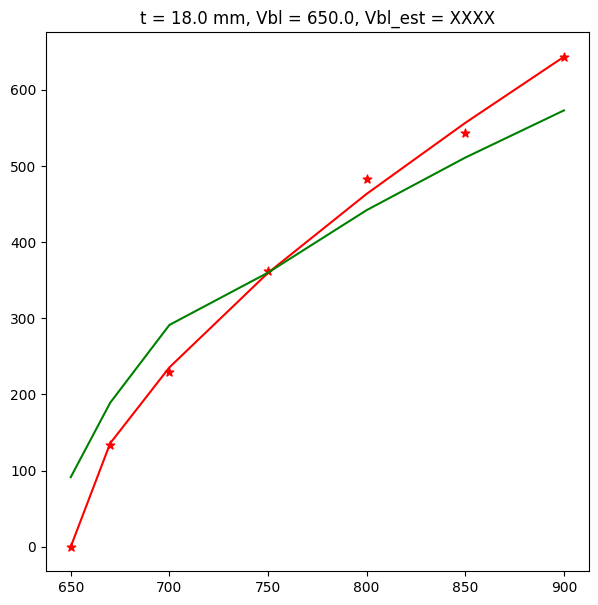

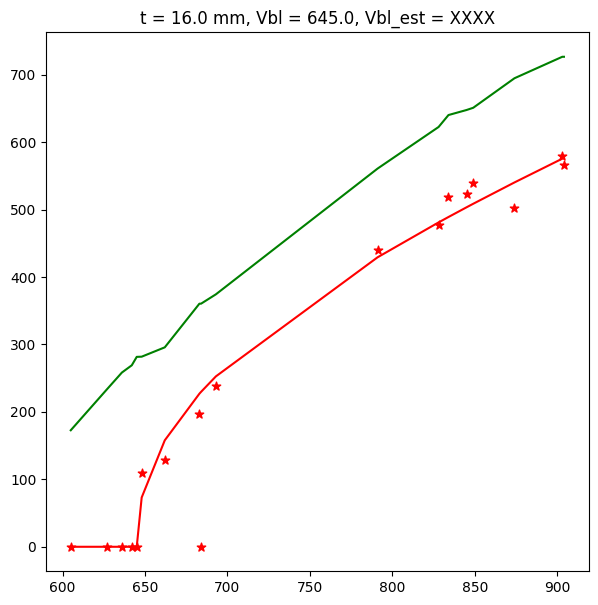

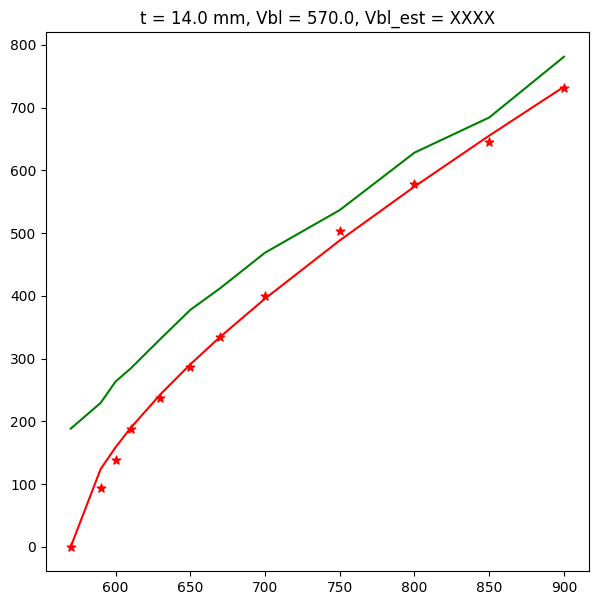

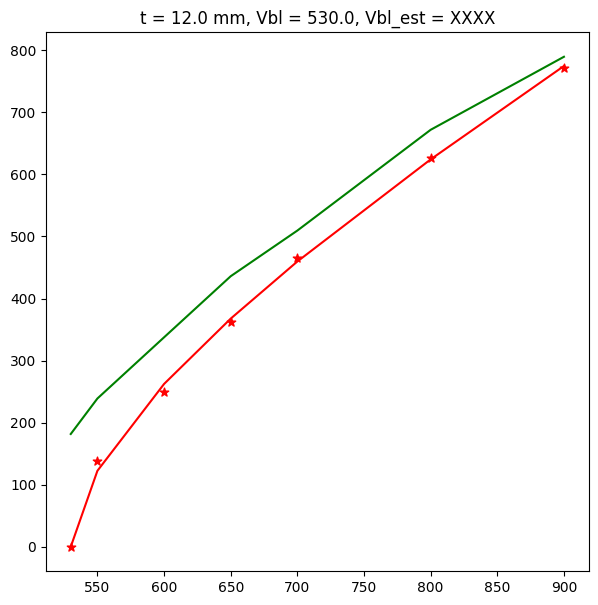

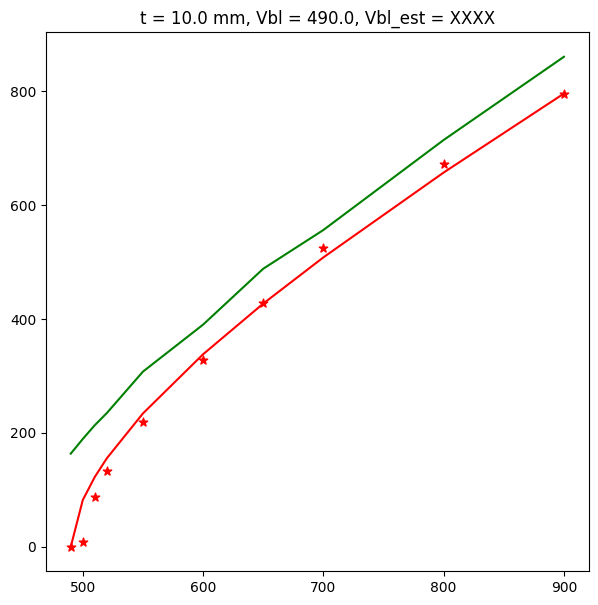

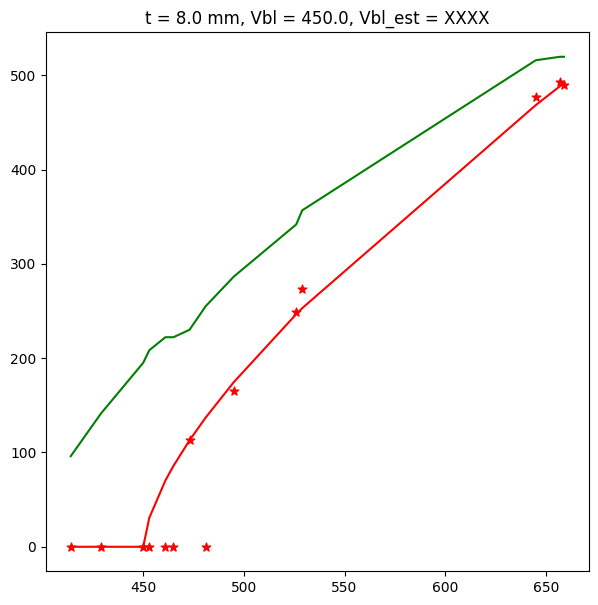

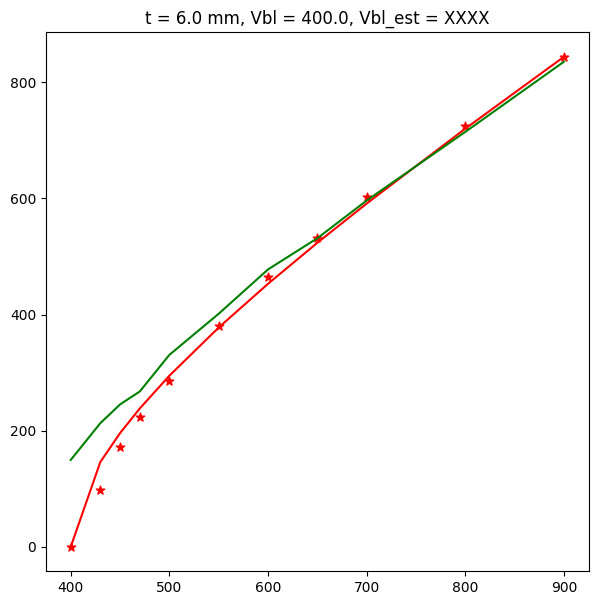

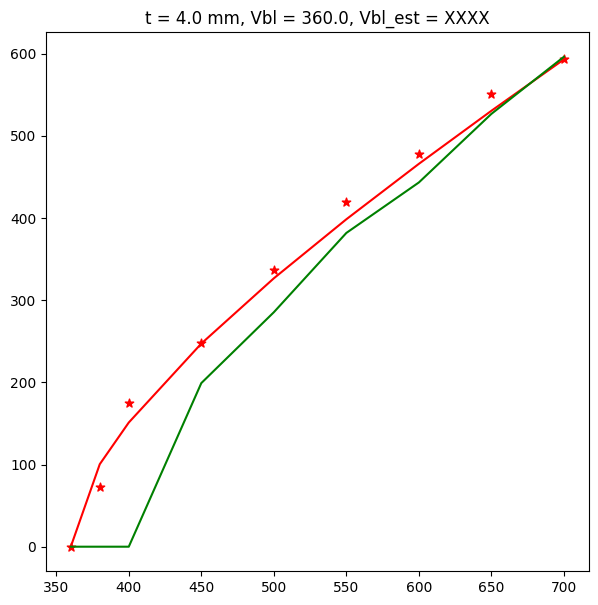

In [13]:

list_vr = []
list_vr_est = []
list_vbl = []
#list_vbl_est = []

for t in wspolczynniki_list:
    path_help = './results/' + folder_name + '/xgb_model_t=' + str(t) + '.pkl'
    with open(path_help, 'rb') as file:
        regr = pickle.load(file)

    fig, ax = plt.subplots(figsize=(7, 7))


    id_color = 0
    wsp = wspolczynniki[wspolczynniki[:,3] == t]
    dd = dane[dane[:,2] == t]
    print('t' + str(wsp))
    #print(dd)
    vbl_ = wsp[0, 0]
    aa_ = wsp[0, 1]
    pp_ = wsp[0, 2]
    #vi_ = make_sequence(0, 1000, 100)
    vi_ = dd[:,0]
    vir_ = Vr(vi_, aa_, pp_, vbl_)


    plt.scatter(dd[:,0], dd[:,1], c=color_list[id_color], label=str(t) + ' mm', marker=markers[id_color], s=40)
    #plt.plot(vi, vir, c=color_list[id_color], ls='-', label='RL,Vbl=%5.0f m/s, a=%5.2f, p=%5.1f' % tuple([vbl, aa,pp]))
    plt.plot(vi_, vir_, c=color_list[id_color], ls='-')

    vr_list = []
    for id_t in range(vi_.shape[0]):
        #vr_list.append(vr_(vi_[id_t], t, p, a, vbl))
        vr_list.append(regr.predict([[vi_[id_t], t]])[0])

    list_vr.append(vir_)
    list_vr_est.append(np.array(vr_list))
    list_vbl.append(vbl_)
    #list_vbl_est.append(vbl(t))

    plt.title("t = " + str(t) + " mm" + ", Vbl = " + str(vbl_) + ", Vbl_est = XXXX")# + str(vbl(t)))
    plt.plot(vi_, vr_list, c=color_list[id_color + 1], ls='-')
    #plt.savefig("./figures/test" + str(round(t,)) + ".eps", dpi=300, format='eps', bbox_inches="tight")

import pickle
with open('errors_for_wilcoxon/xgb.pkl', 'wb') as file:
    pickle.dump((list_vr, list_vr_est, list_vbl, list_vbl_est), file)


In [10]:
t = 8
dd = dane[dane[:,2] == t]
dd[:,0]

array([659., 657., 645., 529., 526., 495., 481., 473., 465., 461., 453.,
       450., 429., 414.])

100%|██████████| 15/15 [00:00<00:00, 35.32it/s]
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


"\nif save_flile is not None:\n        plt.savefig(save_flile, format='eps')\nplt.show()\n"

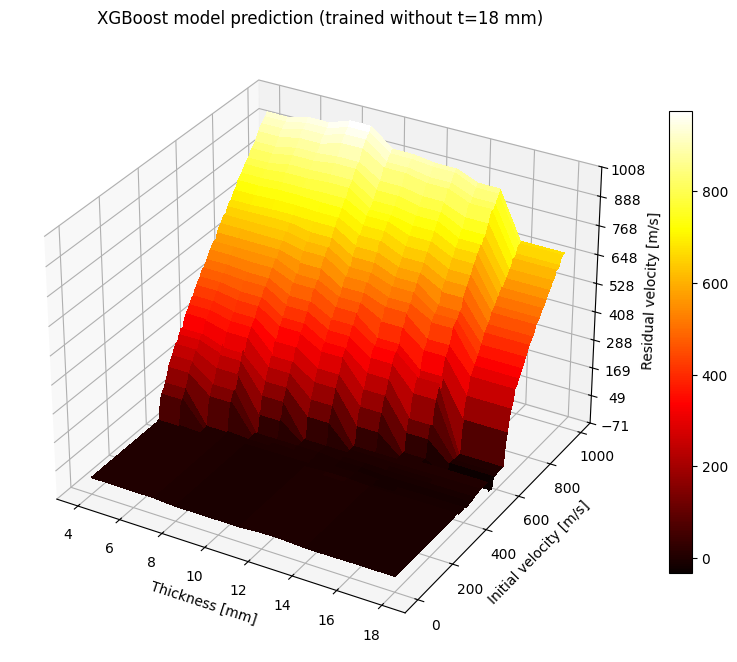

In [22]:
##############################
# Visualization 3d
from matplotlib.ticker import LinearLocator
from tqdm import tqdm
tt = 18
path_help = './results/' + folder_name + '/xgb_model_t=' + str(tt) + '.0.pkl'
with open(path_help, 'rb') as file:
    regr = pickle.load(file)


fig, ax = plt.subplots(subplot_kw={"projection": "3d"}, figsize=(10, 10))
ax.zaxis.set_major_locator(LinearLocator(10))
# A StrMethodFormatter is used automatically
ax.zaxis.set_major_formatter('{x:.0f}')
plt.title('XGBoost model prediction (trained without t=' + str(int(tt)) + ' mm)')
# Add a color bar which maps values to colors.

v_help = np.arange(0, 1000, 10)
t_help = np.arange(4, 19, 1)
v_help, t_help = np.meshgrid(v_help, t_help)
z = np.zeros(v_help.shape)
for x_id in tqdm(range(z.shape[0])):
    for y_id in range(z.shape[1]):
        #z[x_id, y_id] = vr_(v_help[x_id, y_id], t_help[x_id, y_id], p, a, vbl)
        #z[x_id, y_id] = vr_vt_t0(v_help[x_id, y_id], t_help[x_id, y_id], tt)
        z[x_id, y_id] = regr.predict([[v_help[x_id, y_id], t_help[x_id, y_id]]])[0]

ax.set(xlabel=('Thickness [mm]'), ylabel=('Initial velocity [m/s]'), zlabel=('Residual velocity [m/s]'))
# viridis, inferno
surf = ax.plot_surface(t_help, v_help, z, cmap='hot', linewidth=0, antialiased=False)
#ax.view_init(0, 10)
fig.colorbar(surf, shrink=0.6, location='right')
plt.savefig("./figures/xgb_" + str((int(tt))) + "_surf.eps", format='eps', bbox_inches='tight')
"""
if save_flile is not None:
        plt.savefig(save_flile, format='eps')
plt.show()
"""

In [11]:
def rmse(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    return np.sqrt(np.mean((y_true - y_pred) ** 2))

def mae(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    return np.mean(np.abs(y_true - y_pred))

def r2_score(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    ss_res = np.sum((y_true - y_pred) ** 2)            # suma kwadratów reszt
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)   # całkowita wariancja

    return 1 - ss_res / ss_tot

def relative_error(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    eps = 1e-12
    return np.abs(y_true - y_pred) / (np.abs(y_true) + eps)



In [12]:

rmse_list = []
mae_list = []
r2_list = []
id_list = 0

eps = 0.000001

for id_list in range(len(list_vr)):
    id_arr = 0
    while list_vr[id_list][id_arr] < eps and list_vr_est[id_list][id_arr] < eps and id_arr < list_vr[id_list].shape[0]:
            id_arr += 1

    rmse_list.append(rmse(list_vr[id_list][id_arr:list_vr[id_list].shape[0]], list_vr_est[id_list][id_arr:list_vr[id_list].shape[0]]))
    mae_list.append(mae(list_vr[id_list][id_arr:list_vr[id_list].shape[0]], list_vr_est[id_list][id_arr:list_vr[id_list].shape[0]]))
    r2_list.append(r2_score(list_vr[id_list][id_arr:list_vr[id_list].shape[0]], list_vr_est[id_list][id_arr:list_vr[id_list].shape[0]]))

print("RMSE = " + str(np.round(np.mean(rmse_list),3)) + " ± " + str(np.round(np.std(rmse_list),3)))
print("MAE = " + str(np.round(np.mean(mae_list),3)) + " ± " + str(np.round(np.std(mae_list),3)))
print("R2 = " + str(np.round(np.mean(r2_list),3)) + " ± " + str(np.round(np.std(r2_list),3)))

re_vbl = relative_error(list_vbl, list_vbl_est)
rmse_vbl = rmse(list_vbl, list_vbl_est)

print("RE vbl = " + str(np.round(np.mean(re_vbl),3)) + " ± " + str(np.round(np.std(re_vbl),3)))
print("RMSE vbl = " + str(np.round(rmse(list_vbl, list_vbl_est),3)))
print("MAE vbl = " + str(np.round(mae(list_vbl, list_vbl_est),3)))
print("R2 vbl = " + str(np.round(r2_score(list_vbl, list_vbl_est),3)))



RMSE = 93.599 ± 38.906
MAE = 81.782 ± 41.549
R2 = 0.776 ± 0.202
RE vbl = 0.08 ± 0.034
RMSE vbl = 42.809
MAE vbl = 39.125
R2 vbl = 0.818


In [27]:
list_vbl_est

[np.int64(652),
 np.int64(576),
 np.int64(569),
 np.int64(528),
 np.int64(468),
 np.int64(445),
 np.int64(405),
 np.int64(303)]

In [78]:
ssss = 7
print(list_vr[ssss])
print(list_vr_est[ssss])
print(rmse(list_vr[ssss], list_vr_est[ssss]))

[592.99999975 530.48220571 465.92453405 398.47649405 326.62597038
 247.21987717 151.18223175 100.47168884   0.        ]
[635.77930514 564.91086349 492.00099676 416.24334141 336.23142261
 249.11044024 147.04588983  95.91485994  18.94466532]
22.3697651067227


In [91]:
def calculate_help():
    list_vr = []
    list_vr_est = []
    list_vbl = []
    list_vbl_est = []

    for t in wspolczynniki_list:
        #plt.subplots(figsize=(7, 7))
        (p, a, vbl) = get_params_for_thickness(t)

        id_color = 0
        wsp = wspolczynniki[wspolczynniki[:,3] == t]
        dd = dane[dane[:,2] == t]
        print('t' + str(wsp))
        #print(dd)
        vbl_ = wsp[0, 0]
        aa_ = wsp[0, 1]
        pp_ = wsp[0, 2]
        vi_ = make_sequence(0, 1000, 100)
        vir_ = Vr(vi_, aa_, pp_, vbl_)


        #plt.scatter(dd[:,0], dd[:,1], c=color_list[id_color], label=str(t) + ' mm', marker=markers[id_color], s=40)
        #plt.plot(vi, vir, c=color_list[id_color], ls='-', label='RL,Vbl=%5.0f m/s, a=%5.2f, p=%5.1f' % tuple([vbl, aa,pp]))
        #plt.plot(vi_, vir_, c=color_list[id_color], ls='-')

        vr_list = []
        for id_t in range(vi_.shape[0]):
            vr_list.append(vr_(vi_[id_t], t, p, a, vbl))

        list_vr.append(vir_)
        list_vr_est.append(np.array(vr_list))
        list_vbl.append(vbl_)
        list_vbl_est.append(vbl(t))

    return (list_vr, list_vr_est, list_vbl, list_vbl_est)

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


t[[650.           1.18526197   1.69636306  18.        ]]
t[[645.     0.84   2.27  16.  ]]
t[[570.           1.18964452   1.66433168  14.        ]]
t[[530.           1.17723814   1.68443586  12.        ]]
t[[490.           1.1282571    1.74498554  10.        ]]
t[[450.     1.24   1.57   8.  ]]
t[[400.           1.08412729   1.80857956   6.        ]]
t[[360.           1.05086957   1.74480626   4.        ]]
t[[650.           1.18526197   1.69636306  18.        ]]


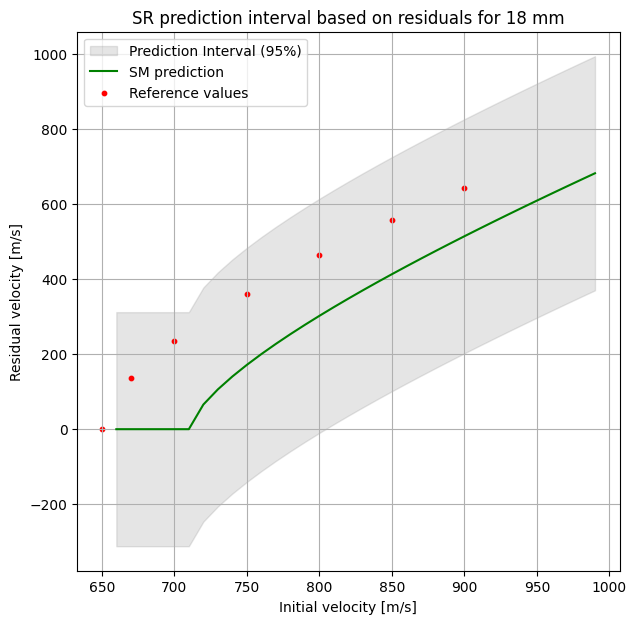

In [110]:
(list_vr_, list_vr_est_, list_vbl_, list_vbl_est_) = calculate_help()

import numpy as np
import matplotlib.pyplot as plt
id_list = 0
id_arr = 0
eps = 0.00001
while list_vr_[id_list][id_arr] < eps and list_vr_est_[id_list][id_arr] < eps and id_arr < list_vr_[id_list].shape[0]:
            id_arr += 1

t = wspolczynniki_list[id_list]

# --- DANE WEJŚCIOWE ---
# vi      - lista wartości X
# vr      - lista wartości rzeczywistych
# vr_exp  - lista błędów (residuów) modelu = vr - y_pred

#vr__ = list_vr[id_list][id_arr:list_vr[id_list].shape[0]]
#vr__est = list_vr_est[id_list][id_arr:list_vr[id_list].shape[0]]
vi = make_sequence(0, 1000, 100)
vi = np.array(vi[id_arr:list_vr_[id_list].shape[0]])
vr = np.array(list_vr_[id_list][id_arr:list_vr_[id_list].shape[0]])
y_pred = np.array(list_vr_est_[id_list][id_arr:list_vr_[id_list].shape[0]])

# --- ODTWORZENIE PREDYKCJI ---
vr_exp = vr - y_pred

# --- OBLICZENIE RMSE ---
rmse = np.sqrt(np.mean(vr_exp**2))

# 95% prediction interval
z = 1.96

from scipy.stats import norm

confidence = 0.95
z = norm.ppf( (1 + confidence) / 2 )

y_lower = y_pred - z * rmse
y_upper = y_pred + z * rmse

# --- WYKRES ---
plt.figure(figsize=(7, 7))
# Prediction Interval
plt.fill_between(vi, y_lower, y_upper, color="gray", alpha=0.2, label="Prediction Interval (95%)")
# Predykcja
plt.plot(vi, y_pred, color="green", label="SM prediction")
# Punkty rzeczywiste
#plt.scatter(vi, vr, label="R-I model values", color="red", s=10)#, alpha=0.6)
##########################################################################

wsp = wspolczynniki[wspolczynniki[:,3] == t]
dd = dane[dane[:,2] == t]
print('t' + str(wsp))
#print(dd)
vbl_ = wsp[0, 0]
aa_ = wsp[0, 1]
pp_ = wsp[0, 2]
#vi_ = make_sequence(0, 1000, 100)
vi_ = dd[:,0]
vir_ = Vr(vi_, aa_, pp_, vbl_)
plt.scatter(vi_, vir_, label="Reference values", color="red", s=10)#, alpha=0.6)
##########################################################################


plt.xlabel('Initial velocity [m/s]')
plt.ylabel('Residual velocity [m/s]')
plt.title("SR prediction interval based on residuals for " + str(round(t,)) + " mm")
plt.legend()
plt.grid(True)
#plt.show()
plt.savefig("./figures/srpi_" + str(round(t,)) + ".eps", dpi=300, format='eps', bbox_inches="tight")


In [88]:
(list_vr_, list_vr_est_, list_vbl_, list_vbl_est_)

([array([  0.        ,   0.        ,   0.        ,   0.        ,
           0.        ,   0.        ,   0.        ,   0.        ,
           0.        ,   0.        ,   0.        ,   0.        ,
           0.        ,   0.        ,   0.        ,   0.        ,
           0.        ,   0.        ,   0.        ,   0.        ,
           0.        ,   0.        ,   0.        ,   0.        ,
           0.        ,   0.        ,   0.        ,   0.        ,
           0.        ,   0.        ,   0.        ,   0.        ,
           0.        ,   0.        ,   0.        ,   0.        ,
           0.        ,   0.        ,   0.        ,   0.        ,
           0.        ,   0.        ,   0.        ,   0.        ,
           0.        ,   0.        ,   0.        ,   0.        ,
           0.        ,   0.        ,   0.        ,   0.        ,
           0.        ,   0.        ,   0.        ,   0.        ,
           0.        ,   0.        ,   0.        ,   0.        ,
           0.        ,   

In [68]:
vi

array([ 0., 10., 20., 30., 40., 50., 60., 70., 80.])